# Network Size Analysis — Precision Functional Mapping

Computes individual network sizes from PFM communities (Gordon17 reference) and compares across groups.

Three approaches are compared:
1. **Vertex count** — number of vertices assigned to each network
2. **Template area** — sum of vertex areas from the fsLR32k group-average surface (`vaavg`), same for all subjects
3. **Individual area** — sum of vertex areas from each subject's own midthickness surface resampled to fsLR32k, capturing individual cortical anatomy

Data: `/mnt_03/ds-dnumrisk/derivatives/pfm_fslr/sub-XX/networks/*_consensus_ref-gordon17_communities.npz`

In [ ]:
import sys
import os.path as op
import warnings

sys.path.insert(0, '/home/ubuntu/git/parietal_patterns/nets_PFM')
from config import ATLAS_NETWORK_NAMES

import numpy as np
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from tqdm.auto import tqdm # Python library that provides a fast, extensible progress bar for loops and iterables, making it easy to visualize the progress of your code

warnings.filterwarnings('ignore')

/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Configuration

In [2]:
# ── Atlas ──────────────────────────────────────────────────────────────────
ATLAS = 'caNets_DDnr'   # 'gordon17' | 'caNets_DDnr'

NETWORK_NAMES = ATLAS_NETWORK_NAMES[ATLAS]

# ── Paths ──────────────────────────────────────────────────────────────────
BIDS_ROOT_LARGE  = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk'
PFM_ROOT         = '/mnt_03/ds-dnumrisk/derivatives/pfm_fslr'
NEUROMAPS_FSLR   = '/home/ubuntu/neuromaps-data/atlases/fsLR'

# ── Subjects ───────────────────────────────────────────────────────────────
SUBJECTS = list(range(1, 67))   # sub-01 … sub-65; extend as needed

## 2. Load group info and shared surface files

In [3]:
# Group assignment
group_df = pd.read_csv(op.join(BIDS_ROOT_LARGE, 'group_assignment.csv')).set_index('subject')
print(group_df.head())
print('Group counts:', group_df['group'].value_counts().to_dict())

         group
subject       
1            0
2            1
3            0
4            1
5            0
Group counts: {0: 33, 1: 33}


In [4]:
from utils_01 import get_template_vertex_area  

tpl_vertex_areas, cortex_mask_L, cortex_mask_R = get_template_vertex_area(NEUROMAPS_FSLR)


Valid cortical nodes: L=29696, R=29716, total=59412
Total template cortical area: 178349 mm² (1783.5 cm²)


## 3. Individual vertex areas in fsLR32k space

Per-subject `.shape.gii` files are pre-computed by `06_comp_indVertexArea.py`
and saved to `pfm_fslr/sub-XX/anat/`. Load them here.

In [6]:
ind_areas_dict = {}
for sub_id in SUBJECTS:
    sub_str = f'sub-{sub_id:02d}'
    areas = []
    ok = True
    for hemi, mask in [('L', cortex_mask_L), ('R', cortex_mask_R)]:
        path = op.join(PFM_ROOT, sub_str, 'anat',
                       f'{sub_str}_ses-1_hemi-{hemi}_vertex_areas_fsLR32k.shape.gii')
        if not op.exists(path):
            print(f'  sub-{sub_id:02d}: missing hemi-{hemi} — run 06_comp_indVertexArea.py')
            ok = False
            break
        va_full = nib.load(path).darrays[0].data  # (32492,)
        areas.append(va_full[mask])               # keep valid cortex only
    if ok:
        ind_areas_dict[sub_id] = np.concatenate(areas)  # (59412,)

print(f'Individual areas loaded for {len(ind_areas_dict)} subjects')

  sub-05: missing hemi-L — run 06_comp_indVertexArea.py
Individual areas loaded for 65 subjects


### QC: compare total individual cortical area across subjects

Total cortical area (valid cortex): 1621.0 ± 138.7 cm²
Template total: 1783.5 cm²


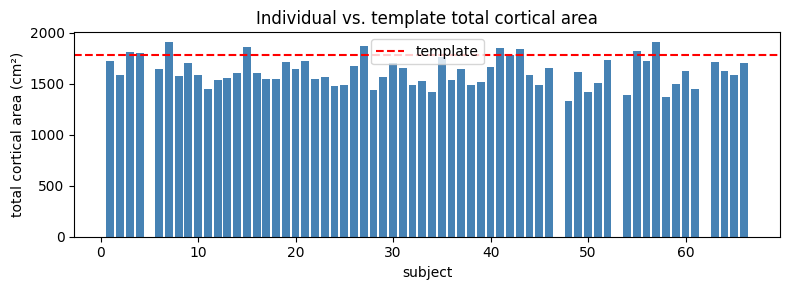

In [12]:
total_ind = {sub: arr.sum() / 100 for sub, arr in ind_areas_dict.items()}   # cm²
print(f'Total cortical area (valid cortex): {np.mean(list(total_ind.values())):.1f} ± {np.std(list(total_ind.values())):.1f} cm²')
print(f'Template total: {tpl_vertex_areas.sum()/100:.1f} cm²')

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(list(total_ind.keys()), list(total_ind.values()), color='steelblue')
ax.axhline(tpl_vertex_areas.sum() / 100, color='red', ls='--', label='template')
ax.set_xlabel('subject'); ax.set_ylabel('total cortical area (cm²)')
ax.set_title('Individual vs. template total cortical area'); ax.legend()
plt.tight_layout(); plt.show()

## 4. Compute network sizes for all subjects

In [13]:
def network_sizes_for_subject(sub_id, method='vertex_count'):
    """Return dict {network_label: size} for one subject.
    
    method: 'vertex_count' | 'template_area' | 'individual_area'
    """
    sub_str = f'sub-{sub_id:02d}'
    net_file = op.join(PFM_ROOT, sub_str, 'networks',
                       f'{sub_str}_ses-1_space-fsLR32k_consensus_ref-{ATLAS}_communities.npz')
    if not op.exists(net_file):
        return None
    data = np.load(net_file)
    labels = data['network_labels']   # (n_valid,), may be < 59412 if some vertices had dropout

    # Align area arrays with whatever nodes survived the valid_mask in step 03
    meta = np.load(op.join(PFM_ROOT, sub_str, 'cm',
                            f'{sub_str}_ses-1_space-fsLR32k_cm_meta.npz'))
    valid_mask = meta['valid_mask']   # (59412,) bool

    if method == 'vertex_count':
        weights = np.ones(len(labels))
    elif method == 'template_area':
        weights = tpl_vertex_areas[valid_mask]
    elif method == 'individual_area':
        if sub_id not in ind_areas_dict:
            return None
        weights = ind_areas_dict[sub_id][valid_mask]
    else:
        raise ValueError(f'Unknown method: {method}')

    if len(weights) != len(labels):
        print(f'  sub-{sub_id:02d}: weight/label mismatch ({len(weights)} vs {len(labels)}) — skipping')
        return None

    unique_labels = np.unique(labels)
    return {lbl: weights[labels == lbl].sum() for lbl in unique_labels}


methods = ['vertex_count', 'template_area', 'individual_area']
results = {m: {} for m in methods}

for sub_id in tqdm(SUBJECTS, desc='subjects'):
    for m in methods:
        r = network_sizes_for_subject(sub_id, method=m)
        if r is not None:
            results[m][sub_id] = r

print('Done. Subjects per method:', {m: len(results[m]) for m in methods})

subjects: 100%|██████████| 66/66 [00:02<00:00, 25.98it/s]

Done. Subjects per method: {'vertex_count': 62, 'template_area': 62, 'individual_area': 62}


In [14]:
def to_dataframe(results_dict, method_name, group_df):
    """Convert results dict to long-form DataFrame."""
    rows = []
    for sub_id, sizes in results_dict.items():
        for lbl, size in sizes.items():
            if lbl == 0:   # skip unassigned
                continue
            rows.append({
                'subject': sub_id,
                'group': group_df.loc[sub_id, 'group'] if sub_id in group_df.index else np.nan,
                'network_id': lbl,
                'network': NETWORK_NAMES.get(lbl, f'Net-{lbl}'),
                'size': size,
                'method': method_name,
            })
    return pd.DataFrame(rows)


dfs = [to_dataframe(results[m], m, group_df) for m in methods]
df_all = pd.concat(dfs, ignore_index=True)

# Convert areas to cm² for readability
df_all.loc[df_all['method'] != 'vertex_count', 'size'] /= 100

print(df_all.head(10))
print(f'Shape: {df_all.shape}')

   subject  group  network_id            network     size        method
0        1      0           2            Visual2   6916.0  vertex_count
1        1      0           3        Somatomotor  10334.0  vertex_count
2        1      0           4  Cingulo-Opercular   9106.0  vertex_count
3        1      0           5   Dorsal-attention   8317.0  vertex_count
4        1      0           7     Frontoparietal   2426.0  vertex_count
5        1      0           8           Auditory   3501.0  vertex_count
6        1      0           9            Default  18476.0  vertex_count
7        2      1           2            Visual2   8143.0  vertex_count
8        2      1           3        Somatomotor  10484.0  vertex_count
9        2      1           4  Cingulo-Opercular  10134.0  vertex_count
Shape: (1314, 6)


## 5. Compare the three size-estimation approaches

In [15]:
# Pivot to wide: one row per subject × network, one column per method
df_wide = df_all.pivot_table(index=['subject', 'network_id', 'network'],
                              columns='method', values='size').reset_index()
df_wide.columns.name = None
df_wide = df_wide.merge(group_df.reset_index(), on='subject', how='left')
df_wide.head()

,subject,network_id,network,individual_area,template_area,vertex_count,group
0,1,2,Visual2,236.288496,265.909082,6916.0,0
1,1,3,Somatomotor,247.275547,249.556113,10334.0,0
2,1,4,Cingulo-Opercular,243.176250,240.089824,9106.0,0
3,1,5,Dorsal-attention,234.028711,243.289316,8317.0,0
4,1,7,Frontoparietal,85.037285,85.101191,2426.0,0


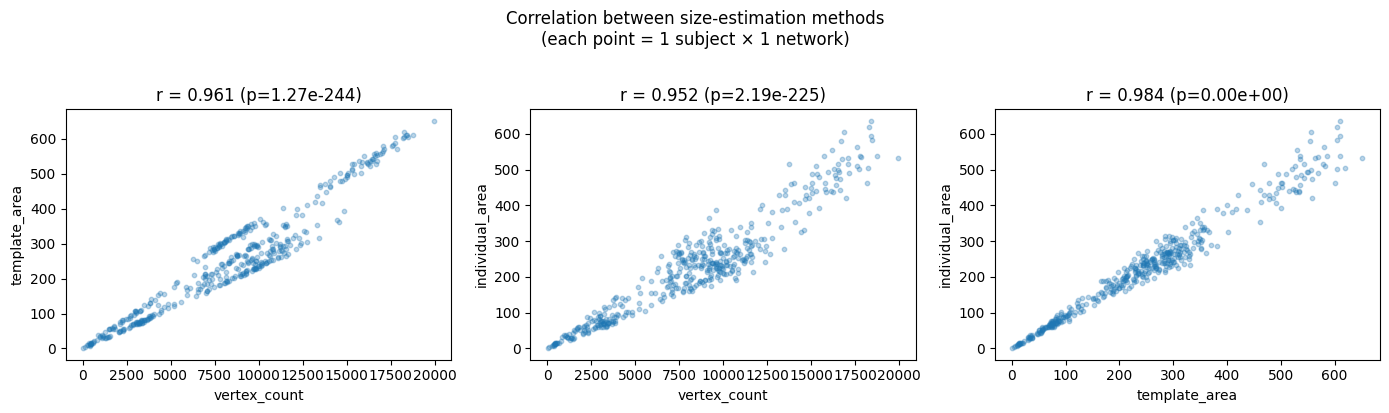

In [16]:
# Correlation between methods across all subjects × networks
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
pairs = [('vertex_count', 'template_area'),
         ('vertex_count', 'individual_area'),
         ('template_area', 'individual_area')]

for ax, (x, y) in zip(axes, pairs):
    ax.scatter(df_wide[x], df_wide[y], alpha=0.3, s=10)
    r, p = stats.pearsonr(df_wide[x].dropna(), df_wide[y].dropna())
    ax.set_xlabel(x); ax.set_ylabel(y)
    ax.set_title(f'r = {r:.3f} (p={p:.2e})')

plt.suptitle('Correlation between size-estimation methods\n(each point = 1 subject × 1 network)',
             y=1.02)
plt.tight_layout(); plt.show()

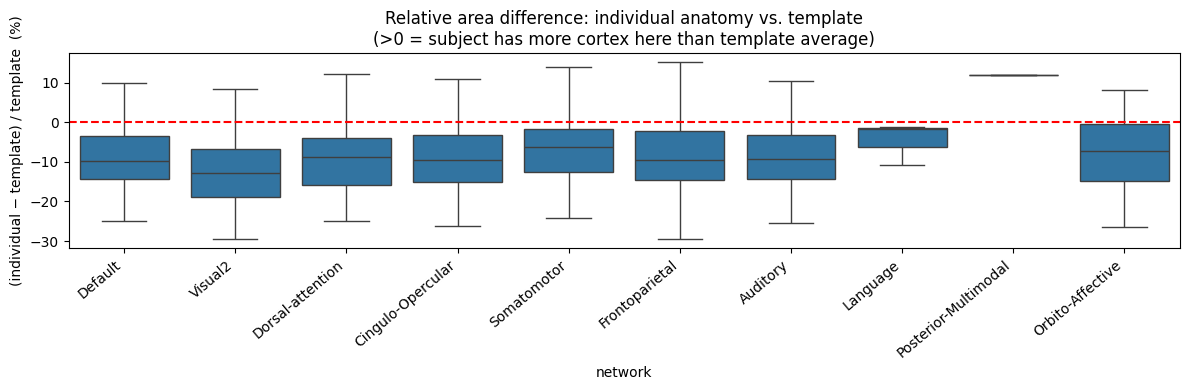

In [17]:
# Relative difference: individual vs. template area (per network, per subject)
df_wide['area_diff_pct'] = (df_wide['individual_area'] - df_wide['template_area']) / df_wide['template_area'] * 100

fig, ax = plt.subplots(figsize=(12, 4))
net_order = df_wide.groupby('network')['individual_area'].mean().sort_values(ascending=False).index
sns.boxplot(data=df_wide, x='network', y='area_diff_pct', order=net_order, ax=ax)
ax.axhline(0, color='red', ls='--')
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right')
ax.set_ylabel('(individual − template) / template  (%)')
ax.set_title('Relative area difference: individual anatomy vs. template\n(>0 = subject has more cortex here than template average)')
plt.tight_layout(); plt.show()

## 6. Network sizes — overview across subjects

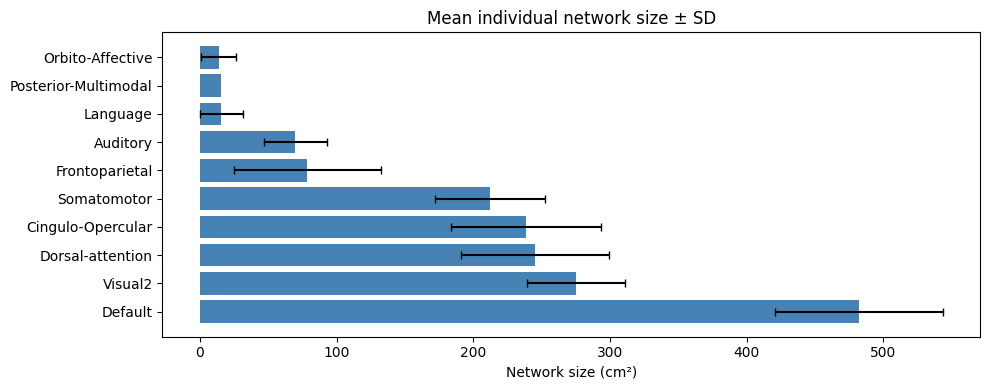

In [18]:
# Mean network size per method (sorted by size)
summary = (df_all[df_all['method'] == 'individual_area']
           .groupby('network')['size']
           .agg(['mean', 'std'])
           .sort_values('mean', ascending=False))

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(summary.index, summary['mean'], xerr=summary['std'],
        color='steelblue', capsize=3)
ax.set_xlabel('Network size (cm²)'); ax.set_title('Mean individual network size ± SD')
plt.tight_layout(); plt.show()

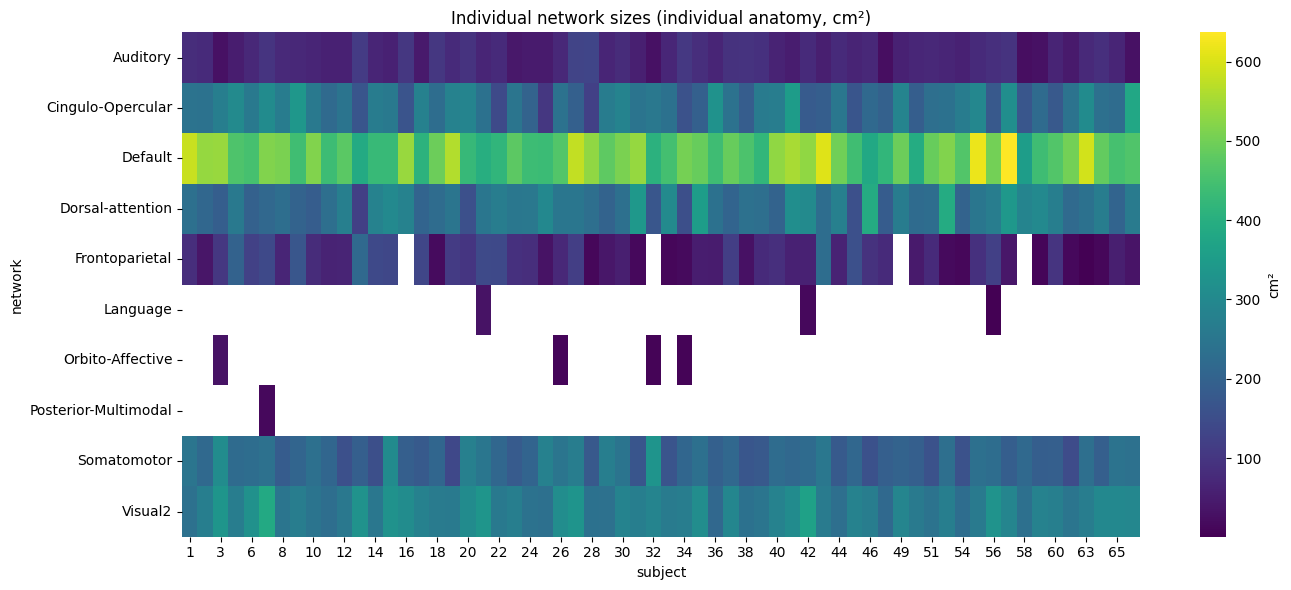

In [19]:
# Subject-level heatmap: network × subject (individual area)
heatmap_data = (df_all[df_all['method'] == 'individual_area']
                .pivot_table(index='network', columns='subject', values='size'))

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(heatmap_data, ax=ax, cmap='viridis', cbar_kws={'label': 'cm²'})
ax.set_title('Individual network sizes (individual anatomy, cm²)')
plt.tight_layout(); plt.show()

## 7. Group comparison

In [20]:
# Focus on individual_area for group comparisons
df_ind = df_all[df_all['method'] == 'individual_area'].copy()
df_ind = df_ind[df_ind['group'].notna()]
df_ind['group'] = df_ind['group'].astype(int)

# Available networks (excluding unassigned)
networks = sorted(df_ind['network'].unique())
print(f'{len(networks)} networks, {df_ind["subject"].nunique()} subjects')
print('Group counts:', df_ind.drop_duplicates('subject')['group'].value_counts().to_dict())

10 networks, 62 subjects
Group counts: {1: 32, 0: 30}


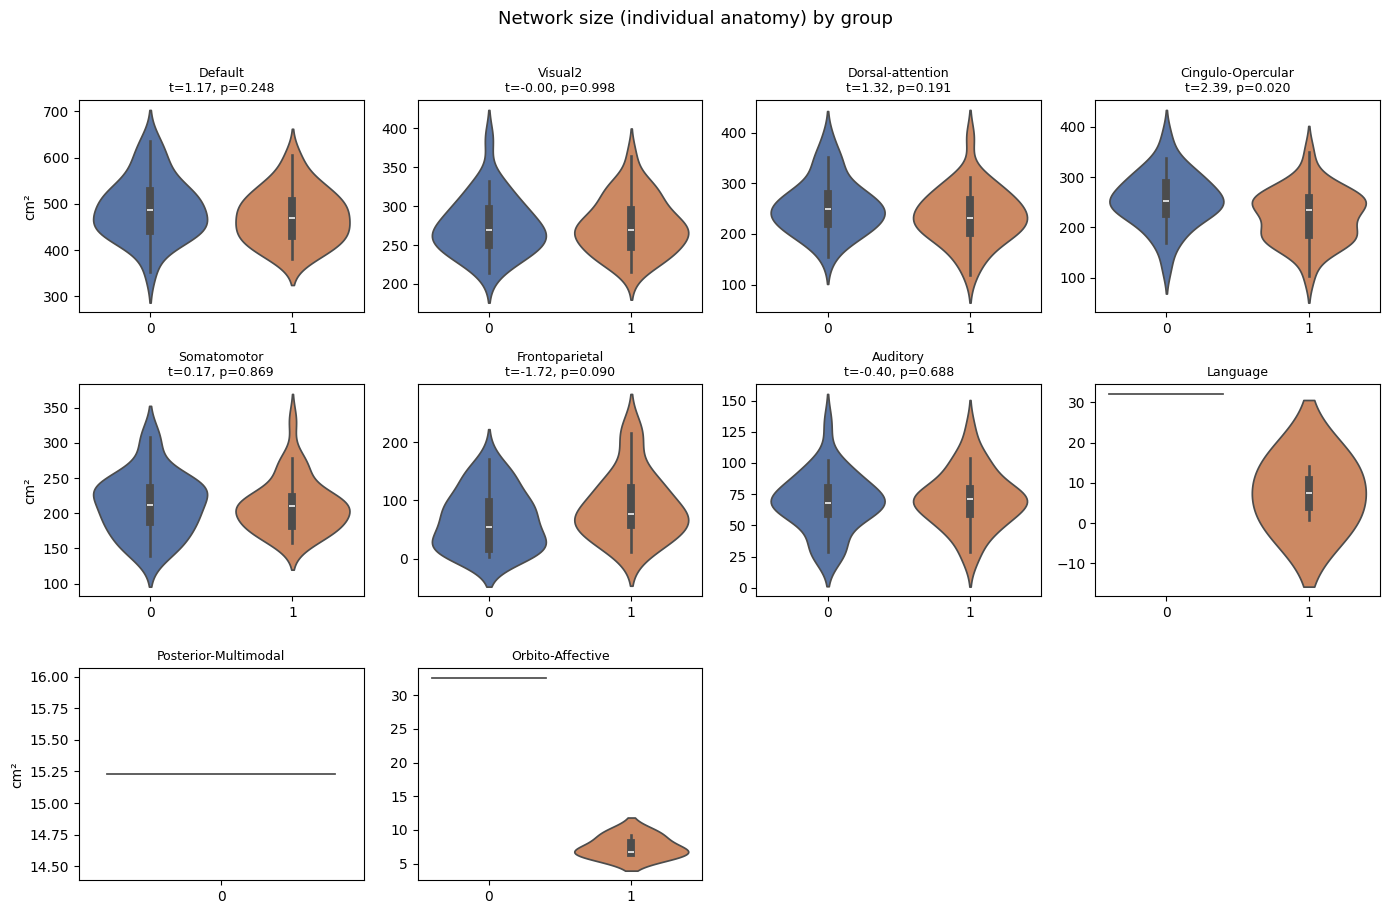

In [22]:
# Violin plots per network, split by group
n_nets = len(networks)
ncols = 4
nrows = int(np.ceil(n_nets / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3))
axes = axes.flatten()

palette = {str(0): '#4C72B0', str(1): '#DD8452'}

for i, net in enumerate(sorted(networks,
        key=lambda n: df_ind[df_ind['network'] == n]['size'].mean(), reverse=True)):
    ax = axes[i]
    sub_data = df_ind[df_ind['network'] == net]
    sns.violinplot(data=sub_data, x='group', y='size', palette=palette,
                   inner='box', ax=ax)

    # T-test
    g0 = sub_data[sub_data['group'] == 0]['size'].values
    g1 = sub_data[sub_data['group'] == 1]['size'].values
    if len(g0) > 1 and len(g1) > 1:
        t, p = stats.ttest_ind(g0, g1)
        ax.set_title(f'{net}\nt={t:.2f}, p={p:.3f}', fontsize=9)
    else:
        ax.set_title(net, fontsize=9)

    ax.set_xlabel(''); ax.set_ylabel('cm²' if i % ncols == 0 else '')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Network size (individual anatomy) by group', y=1.01, fontsize=13)
plt.tight_layout(); plt.show()

In [23]:
# Summary statistics table + uncorrected t-tests
rows = []
for net in networks:
    sub_data = df_ind[df_ind['network'] == net]
    g0 = sub_data[sub_data['group'] == 0]['size'].values
    g1 = sub_data[sub_data['group'] == 1]['size'].values
    t, p = stats.ttest_ind(g0, g1) if (len(g0) > 1 and len(g1) > 1) else (np.nan, np.nan)
    rows.append({
        'network': net,
        'group0_mean': g0.mean() if len(g0) else np.nan,
        'group0_std':  g0.std()  if len(g0) else np.nan,
        'group1_mean': g1.mean() if len(g1) else np.nan,
        'group1_std':  g1.std()  if len(g1) else np.nan,
        't': t, 'p_uncorrected': p,
    })

stats_df = (pd.DataFrame(rows)
            .sort_values('p_uncorrected')
            .reset_index(drop=True))

# Bonferroni correction
n_tests = stats_df['p_uncorrected'].notna().sum()
stats_df['p_bonferroni'] = (stats_df['p_uncorrected'] * n_tests).clip(upper=1.0)

pd.set_option('display.float_format', '{:.3f}'.format)
display(stats_df)

,network,group0_mean,group0_std,group1_mean,group1_std,t,p_uncorrected,p_bonferroni
0,Cingulo-Opercular,255.116,52.519,222.931,51.567,2.395,0.020,0.138
1,Frontoparietal,66.766,48.516,90.742,55.372,-1.723,0.090,0.632
2,Dorsal-attention,254.602,52.426,236.482,53.585,1.323,0.191,1.000
3,Default,491.390,64.330,473.230,56.070,1.168,0.248,1.000
4,Auditory,68.430,23.171,70.808,22.444,-0.404,0.688,1.000
5,Somatomotor,212.983,42.534,211.271,37.642,0.165,0.869,1.000
6,Visual2,275.099,36.541,275.118,34.668,-0.002,0.998,1.000
7,Language,32.120,0.000,7.399,6.706,NaN,NaN,NaN
8,Orbito-Affective,32.574,0.000,7.509,1.286,NaN,NaN,NaN
9,Posterior-Multimodal,15.228,0.000,NaN,NaN,NaN,NaN,NaN


## 8. Vertex count vs. individual area: does anatomy matter for group differences?

If cortical anatomy is different between groups, vertex count and area-based measures may give different answers.

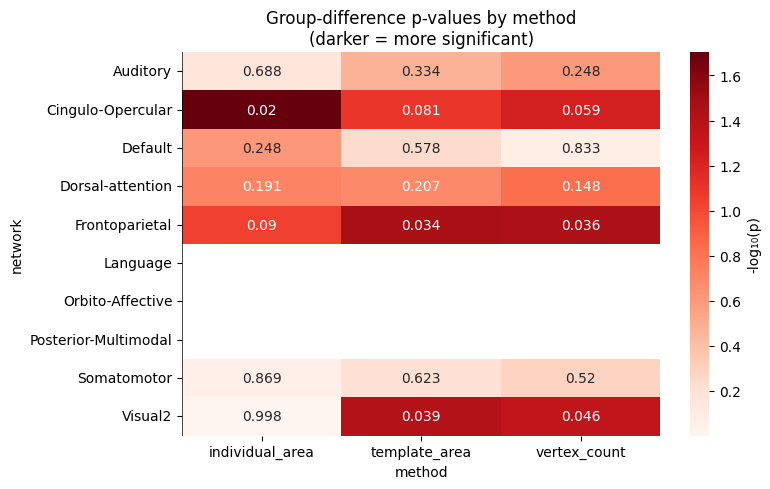

In [24]:
# Compute p-values for all three methods, compare
pval_rows = []
for m in methods:
    df_m = df_all[df_all['method'] == m].copy()
    df_m = df_m[df_m['group'].notna()]
    df_m['group'] = df_m['group'].astype(int)
    for net in networks:
        sub_data = df_m[df_m['network'] == net]
        g0 = sub_data[sub_data['group'] == 0]['size'].values
        g1 = sub_data[sub_data['group'] == 1]['size'].values
        _, p = stats.ttest_ind(g0, g1) if (len(g0) > 1 and len(g1) > 1) else (np.nan, np.nan)
        pval_rows.append({'method': m, 'network': net, 'p': p})

pval_df = pd.DataFrame(pval_rows).pivot(index='network', columns='method', values='p')

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(-np.log10(pval_df.astype(float)), ax=ax, cmap='Reds',
            annot=pval_df.round(3).astype(str), fmt='',
            cbar_kws={'label': '-log₁₀(p)'})
ax.axvline(x=0, color='k', lw=0.5)
ax.set_title('Group-difference p-values by method\n(darker = more significant)')
plt.tight_layout(); plt.show()

## 9. Total cortical area assigned to each group

Check whether total assigned/unassigned vertex proportions differ between groups.

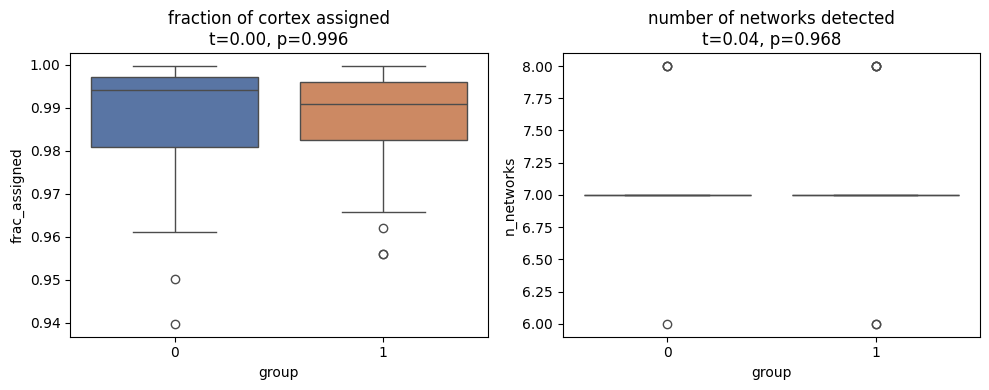

      frac_assigned                                           n_networks  \
              count  mean   std   min   25%   50%   75%   max      count   
group                                                                      
0            30.000 0.987 0.015 0.940 0.981 0.994 0.997 1.000     30.000   
1            32.000 0.987 0.013 0.956 0.982 0.991 0.996 1.000     32.000   

                                                 
       mean   std   min   25%   50%   75%   max  
group                                            
0     7.067 0.365 6.000 7.000 7.000 7.000 8.000  
1     7.062 0.435 6.000 7.000 7.000 7.000 8.000  


In [25]:
# Fraction of cortex assigned (non-zero) per subject
frac_rows = []
for sub_id in SUBJECTS:
    sub_str = f'sub-{sub_id:02d}'
    net_file = op.join(PFM_ROOT, sub_str, 'networks',
                       f'{sub_str}_ses-1_space-fsLR32k_consensus_ref-{ATLAS}_communities.npz')
    if not op.exists(net_file):
        continue
    labels = np.load(net_file)['network_labels']
    assigned = (labels > 0).sum()
    total = len(labels)
    frac_rows.append({
        'subject': sub_id,
        'group': group_df.loc[sub_id, 'group'] if sub_id in group_df.index else np.nan,
        'frac_assigned': assigned / total,
        'n_assigned': assigned,
        'n_networks': len(np.unique(labels[labels > 0]))
    })

frac_df = pd.DataFrame(frac_rows)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col, ylabel in zip(axes,
                            ['frac_assigned', 'n_networks'],
                            ['fraction of cortex assigned', 'number of networks detected']):
    sns.boxplot(data=frac_df, x='group', y=col, palette=palette, ax=ax)
    g0 = frac_df[frac_df['group'] == 0][col].values
    g1 = frac_df[frac_df['group'] == 1][col].values
    t, p = stats.ttest_ind(g0, g1)
    ax.set_title(f'{ylabel}\nt={t:.2f}, p={p:.3f}')

plt.tight_layout(); plt.show()
print(frac_df.groupby('group')[['frac_assigned', 'n_networks']].describe())